# 01. Clustering Algorithms
**Algorithms implemented:** K-Means, Modified K-Means (K-Means++ / Bisecting), Hierarchical (Ward), Fuzzy C-Means.

**Dataset:** Mall Customers (`data/mall_customers.csv`) - Annual Income vs Spending Score.


In [1]:
# ---- Core numerical and plotting libraries ----
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Scikit-Learn clustering models ----
from sklearn.cluster import KMeans, BisectingKMeans, AgglomerativeClustering
# ---- Feature scaling + unsupervised evaluation metrics ----
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
# ---- SciPy hierarchical clustering utilities (linkage + dendrogram) ----
from scipy.cluster.hierarchy import dendrogram, linkage

# Styling setup (consistent look across all notebooks)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

# Fix the random seed so every run reproduces the same results
np.random.seed(42)
print("Libraries successfully imported!")


Libraries successfully imported!


In [2]:
# ---- Load the Mall Customers dataset ----
df_mall = pd.read_csv('../data/mall_customers.csv')
print("Dataset Shape:", df_mall.shape)
print(df_mall.head(3))

# ---- Feature selection: two features so the clusters can be shown in 2D ----
X_mall = df_mall[['Annual Income (k$)', 'Spending Score (1-100)']].values

# ---- Standardize (mean = 0, std = 1): distance-based algorithms are scale-sensitive ----
scaler = StandardScaler()
X_mall_scaled = scaler.fit_transform(X_mall)


Dataset Shape: (200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6


## 1. K-Means Clustering

### Step-by-Step Algorithm (Lloyd's K-Means)
1. **Choose K** and initialize K centroids (here with K-Means++ for a strong start).
2. **Assignment step:** assign every sample to the nearest centroid (Euclidean distance).
3. **Update step:** move each centroid to the mean of the samples assigned to it.
4. **Repeat** steps 2-3 until assignments/centroids stop changing or the iteration limit is reached.
5. **Output:** final centroids, hard cluster labels, and the inertia (WCSS) used for model selection.

### How K Is Selected in This Notebook
1. Fit K-Means for K = 2...10.
2. Record inertia (elbow curve) and silhouette score for each K.
3. Pick the K at the "elbow" / highest silhouette (K = 5 here) and refit the final model.

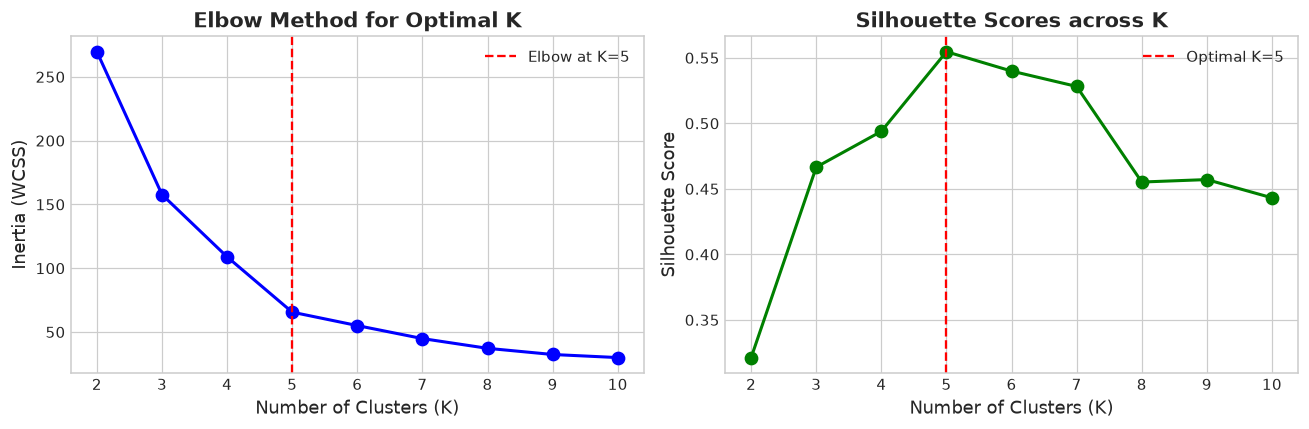

In [3]:
# ---- Selecting the optimal number of clusters K ----
# Try K = 2..10 and record two diagnostics:
#   * Inertia (WCSS): total squared distance from points to their centroid
#   * Silhouette score: cluster cohesion vs. separation
k_range = range(2, 11)
wcss = []
silhouette_scores = []

for k in k_range:
    # n_init=10 runs K-Means from 10 different seeds and keeps the best run
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_mall_scaled)
    wcss.append(kmeans.inertia_)                                               # WCSS of the fitted model
    silhouette_scores.append(silhouette_score(X_mall_scaled, kmeans.labels_))  # partition quality

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ---- Left: elbow curve (look for the "knee" where inertia stops falling quickly) ----
ax1.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
ax1.set_title("Elbow Method for Optimal K", fontsize=14, fontweight='bold')
ax1.set_xlabel("Number of Clusters (K)", fontsize=12)
ax1.set_ylabel("Inertia (WCSS)", fontsize=12)
ax1.axvline(x=5, color='r', linestyle='--', label='Elbow at K=5')
ax1.legend()

# ---- Right: silhouette score for each K (higher is better) ----
ax2.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_title("Silhouette Scores across K", fontsize=14, fontweight='bold')
ax2.set_xlabel("Number of Clusters (K)", fontsize=12)
ax2.set_ylabel("Silhouette Score", fontsize=12)
ax2.axvline(x=5, color='r', linestyle='--', label='Optimal K=5')
ax2.legend()

plt.tight_layout()
plt.show()


In [4]:
# ---- Final K-Means model with the selected K = 5 ----
optimal_k = 5
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', n_init=20, random_state=42)
kmeans_labels = kmeans_model.fit_predict(X_mall_scaled)  # hard cluster assignment per sample

print(f"K-Means Silhouette Score: {silhouette_score(X_mall_scaled, kmeans_labels):.4f}")
print(f"K-Means Davies-Bouldin Index: {davies_bouldin_score(X_mall_scaled, kmeans_labels):.4f}")


K-Means Silhouette Score: 0.5547
K-Means Davies-Bouldin Index: 0.5722


## 2. Modified K-Means

### Step-by-Step Algorithm (Modified K-Means Variants)
**A. K-Means++ initialization**
1. Pick the first centroid uniformly at random from the data.
2. For every point compute D(x)^2 = squared distance to the nearest chosen centroid.
3. Pick the next centroid randomly with probability proportional to D(x)^2.
4. Repeat steps 2-3 until K centroids are chosen, then run standard K-Means.
*Benefit:* avoids poor random starts, converges faster and more consistently.

**B. Bisecting K-Means (divisive)**
1. Start with all samples in a single cluster.
2. Select the cluster with the largest inertia (or largest size).
3. Split it into two using 2-means (try multiple restarts, keep the split with the lowest SSE).
4. Repeat steps 2-3 until exactly K clusters are obtained.
*Benefit:* more balanced, stable cluster sizes and less sensitivity to initialization.

In [5]:
# ---- Modified K-Means ----
# (a) K-Means++ initialization is already used in the standard model above.
# (b) Bisecting K-Means repeatedly splits the cluster with the largest inertia until K clusters.
bisecting_km = BisectingKMeans(n_clusters=optimal_k, random_state=42, bisecting_strategy='biggest_inertia')
bisecting_labels = bisecting_km.fit_predict(X_mall_scaled)

print(f"Bisecting K-Means Silhouette Score: {silhouette_score(X_mall_scaled, bisecting_labels):.4f}")
print(f"Bisecting K-Means Davies-Bouldin Index: {davies_bouldin_score(X_mall_scaled, bisecting_labels):.4f}")


Bisecting K-Means Silhouette Score: 0.4807
Bisecting K-Means Davies-Bouldin Index: 0.6788


## 3. Hierarchical Clustering (Agglomerative)

### Step-by-Step Algorithm (Agglomerative / Ward)
1. Start with N singleton clusters (one per sample).
2. Compute pairwise distances between all clusters using Ward's criterion: ΔW(A,B) = (n_A n_B)/(n_A+n_B) · ||μ_A − μ_B||².
3. Merge the two clusters with the smallest ΔW (least increase in within-cluster variance).
4. Update distances between the new cluster and all remaining clusters.
5. Repeat steps 3-4 until a single cluster remains.
6. Cut the dendrogram at the chosen height (or choose K) to obtain the final partition.

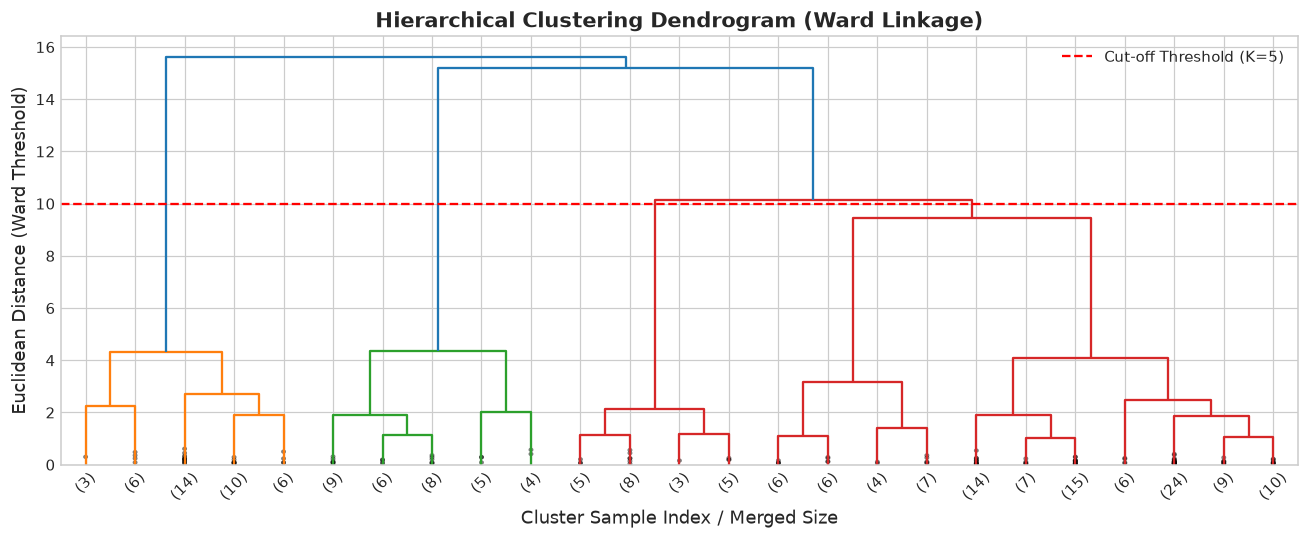

In [6]:
# ---- Build the linkage matrix and draw the dendrogram ----
# 'ward' linkage merges the pair of clusters that increases within-cluster variance the least.
linkage_matrix = linkage(X_mall_scaled, method='ward')

# The dendrogram shows every merge; we truncate it to the last 25 merges for readability.
plt.figure(figsize=(12, 5))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',   # show only the last p merged clusters
    p=25,
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True     # condensed leaves are shown as counts
)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)", fontsize=14, fontweight='bold')
plt.xlabel("Cluster Sample Index / Merged Size", fontsize=12)
plt.ylabel("Euclidean Distance (Ward Threshold)", fontsize=12)
plt.axhline(y=10.0, color='r', linestyle='--', label='Cut-off Threshold (K=5)')  # horizontal cut => cluster count
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
# ---- Fit the final Agglomerative model (Ward linkage, K = 5) ----
agg_model = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
agg_labels = agg_model.fit_predict(X_mall_scaled)

print(f"Hierarchical Silhouette Score: {silhouette_score(X_mall_scaled, agg_labels):.4f}")
print(f"Hierarchical Davies-Bouldin Index: {davies_bouldin_score(X_mall_scaled, agg_labels):.4f}")


Hierarchical Silhouette Score: 0.5538
Hierarchical Davies-Bouldin Index: 0.5779


## 4. Fuzzy C-Means (FCM)

### Step-by-Step Algorithm (Fuzzy C-Means)
1. Choose K, fuzzifier m > 1 and tolerance ε; initialize the membership matrix U randomly so each row sums to 1.
2. **Centroid update:** v_k = Σ_i u_ik^m x_i / Σ_i u_ik^m.
3. **Membership update:** u_ik = 1 / Σ_j (||x_i − v_k|| / ||x_i − v_j||)^(2/(m−1)).
4. **Repeat** steps 2-3 until max |U_new − U_old| < ε or the iteration limit is reached.
5. **Output:** fuzzy memberships u_ik (soft assignment) and centroids; hard labels come from argmax_k u_ik.

In [8]:
class FuzzyCMeans:
    """
    Fuzzy C-Means (FCM) clustering - implemented from scratch with NumPy.

    Each sample belongs to every cluster with a membership degree u_ik in [0, 1],
    and the memberships over the K clusters sum to 1 per sample.

    Parameters
    ----------
    n_clusters   : number of fuzzy clusters K
    m            : fuzzifier exponent (m > 1; larger m => fuzzier memberships)
    max_iter     : maximum number of alternating-optimization iterations
    tol          : convergence tolerance on the maximum membership change
    random_state : seed for reproducible random initialization
    """

    def __init__(self, n_clusters=5, m=2.0, max_iter=150, tol=1e-5, random_state=42):
        self.n_clusters = n_clusters
        self.m = m
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

    def fit(self, X):
        rng = np.random.RandomState(self.random_state)
        n_samples = X.shape[0]

        # Step 1: initialize the membership matrix U randomly and normalize every row to sum to 1
        U = rng.rand(n_samples, self.n_clusters)
        U = U / U.sum(axis=1, keepdims=True)

        # Step 2: alternate between centroid and membership updates until convergence
        for iteration in range(self.max_iter):
            U_old = U.copy()

            # 2a: centroid update - membership-weighted mean of the data
            Um = U ** self.m                                        # u_ik^m
            centers = np.dot(Um.T, X) / Um.sum(axis=0)[:, np.newaxis]

            # 2b: compute the (n_samples x n_clusters) distance matrix to every centroid
            dist = np.linalg.norm(X[:, np.newaxis, :] - centers[np.newaxis, :, :], axis=2)
            dist = np.fmax(dist, 1e-10)  # avoid division by zero

            # 2c: membership update - closer points receive higher membership
            #     u_ik = 1 / sum_j (d_ik / d_ij)^(2/(m-1))
            inv_dist = 1.0 / dist
            power = 2.0 / (self.m - 1.0)
            inv_dist_p = inv_dist ** power
            U = inv_dist_p / inv_dist_p.sum(axis=1, keepdims=True)

            # 2d: stop when memberships stop changing (convergence)
            if np.max(np.abs(U - U_old)) < self.tol:
                break

        # Store results: final centroids, full membership matrix, and hard labels
        self.cluster_centers_ = centers
        self.u_ = U
        self.labels_ = np.argmax(U, axis=1)  # hard assignment = cluster with maximum membership
        return self


# Fit FCM with the same K as the other algorithms (m = 2 is the standard fuzzifier)
fcm = FuzzyCMeans(n_clusters=optimal_k, m=2.0, random_state=42)
fcm.fit(X_mall_scaled)
fcm_labels = fcm.labels_
fcm_centers = scaler.inverse_transform(fcm.cluster_centers_)

# ---- Evaluation of the hard partition induced by the fuzzy memberships ----
print(f"FCM Silhouette Score: {silhouette_score(X_mall_scaled, fcm_labels):.4f}")
print(f"FCM Davies-Bouldin Index: {davies_bouldin_score(X_mall_scaled, fcm_labels):.4f}")


FCM Silhouette Score: 0.5547
FCM Davies-Bouldin Index: 0.5722


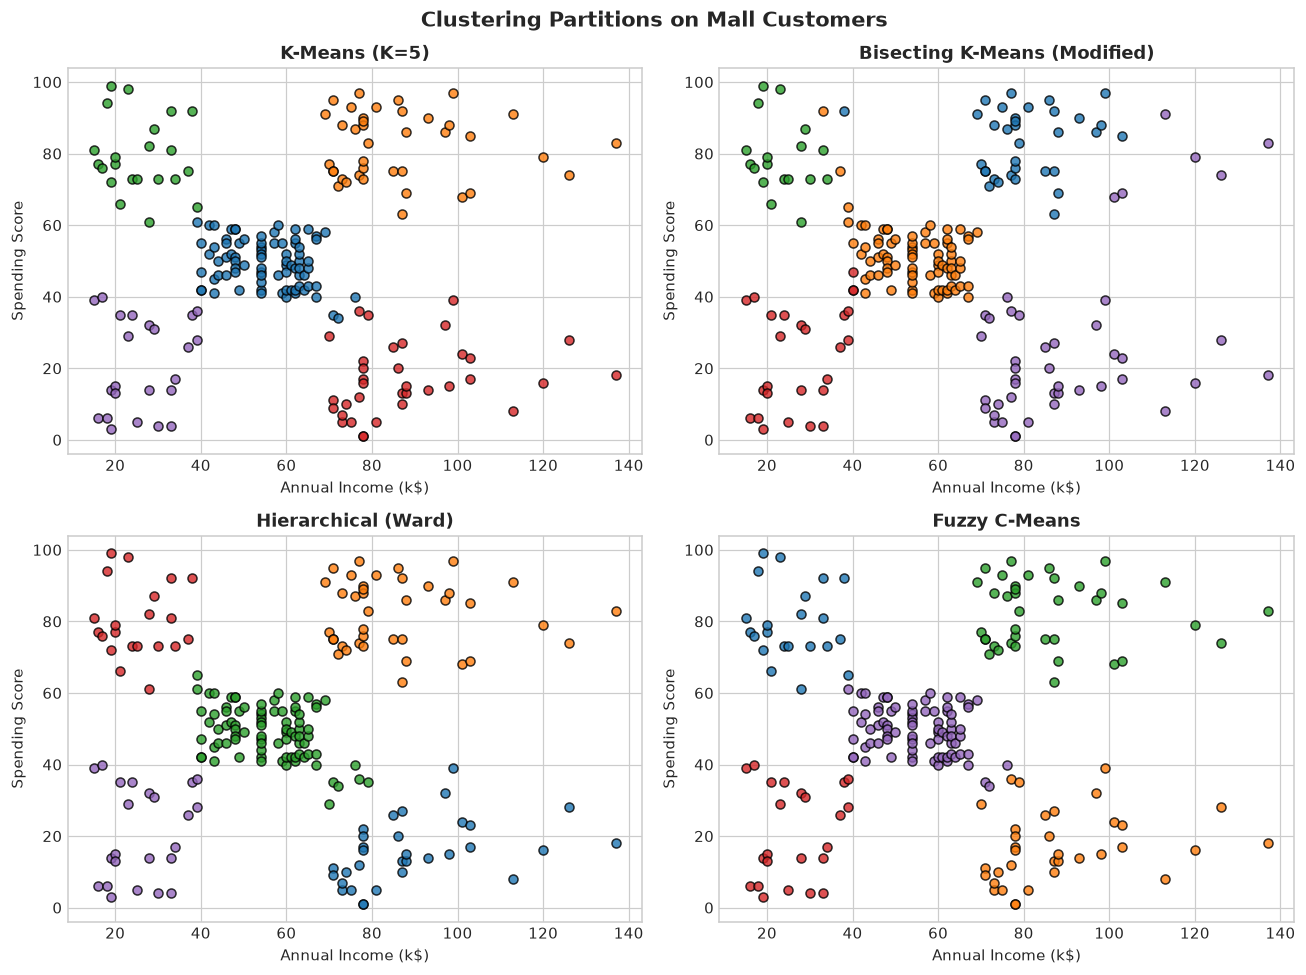

In [9]:
# ---- One combined view of all four clustering partitions ----
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
partitions = [
    ("K-Means (K=5)", kmeans_labels),
    ("Bisecting K-Means (Modified)", bisecting_labels),
    ("Hierarchical (Ward)", agg_labels),
    ("Fuzzy C-Means", fcm_labels),
]
for ax, (title, labels) in zip(axes.flat, partitions):
    for cluster_id in range(optimal_k):
        pts = X_mall[labels == cluster_id]
        ax.scatter(pts[:, 0], pts[:, 1], s=35, edgecolors='k', alpha=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Annual Income (k$)")
    ax.set_ylabel("Spending Score")

plt.suptitle("Clustering Partitions on Mall Customers", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Summary
All four algorithms are evaluated on the standardized features with the same three
unsupervised metrics (Silhouette higher = better, Davies-Bouldin lower = better,
Calinski-Harabasz higher = better).


In [10]:
# ---- Collect the labels produced by the four algorithms ----
models = {
    "Standard K-Means": kmeans_labels,
    "Bisecting K-Means": bisecting_labels,
    "Hierarchical (Ward)": agg_labels,
    "Fuzzy C-Means": fcm_labels
}

# ---- Compute the three unsupervised quality metrics for each partition ----
results = []
for name, labels in models.items():
    results.append({
        "Algorithm": name,
        "Silhouette Score": silhouette_score(X_mall_scaled, labels),                # higher is better
        "Davies-Bouldin Index": davies_bouldin_score(X_mall_scaled, labels),        # lower is better
        "Calinski-Harabasz Score": calinski_harabasz_score(X_mall_scaled, labels)   # higher is better
    })

df_comparison = pd.DataFrame(results).set_index("Algorithm")
print("Clustering Performance Comparison on Mall Customers:")
# Highlight the best value of each metric in green for quick comparison
display(df_comparison.style.highlight_max(subset=['Silhouette Score', 'Calinski-Harabasz Score'], color='lightgreen')
                           .highlight_min(subset=['Davies-Bouldin Index'], color='lightgreen'))


Clustering Performance Comparison on Mall Customers:


,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
Algorithm,,,
Standard K-Means,0.554657,0.572236,248.649320
Bisecting K-Means,0.480684,0.678789,150.938872
Hierarchical (Ward),0.553809,0.577862,244.410326
Fuzzy C-Means,0.554657,0.572236,248.649320
